<a href="https://colab.research.google.com/github/tanmayghosh01-hue/Card-fraud-loss-analysis/blob/main/Credit_Card_Transactions_Fraud_Detection_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Credit Card Fraud Quantification

In [3]:
# Downloading and Importing Kaggle Dataset
!pip install -q kagglehub

In [4]:
import kagglehub

path = kagglehub.dataset_download("kartik2112/fraud-detection")

print(path)

Using Colab cache for faster access to the 'fraud-detection' dataset.
/kaggle/input/fraud-detection


In [5]:
import os

os.listdir(path)

['fraudTest.csv', 'fraudTrain.csv']

In [6]:
import pandas as pd

train = pd.read_csv(path + "/fraudTrain.csv")
test = pd.read_csv(path + "/fraudTest.csv")

In [7]:
# Checking Fraud Test Csv
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [8]:
# Checking Fraud Train Csv
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [9]:
# Concatenate tables
df = pd.concat([train, test], ignore_index=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   trans_date_trans_time  object 
 2   cc_num                 int64  
 3   merchant               object 
 4   category               object 
 5   amt                    float64
 6   first                  object 
 7   last                   object 
 8   gender                 object 
 9   street                 object 
 10  city                   object 
 11  state                  object 
 12  zip                    int64  
 13  lat                    float64
 14  long                   float64
 15  city_pop               int64  
 16  job                    object 
 17  dob                    object 
 18  trans_num              object 
 19  unix_time              int64  
 20  merch_lat              float64
 21  merch_long             float64
 22  is_fraud          

In [11]:
df[df['is_fraud'] == 1]

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
2449,2449,2019-01-02 01:06:37,4613314721966,fraud_Rutherford-Mertz,grocery_pos,281.06,Jason,Murphy,M,542 Steve Curve Suite 011,...,35.9946,-81.7266,885,Soil scientist,1988-09-15,e8a81877ae9a0a7f883e15cb39dc4022,1325466397,36.430124,-81.179483,1
2472,2472,2019-01-02 01:47:29,340187018810220,"fraud_Jenkins, Hauck and Friesen",gas_transport,11.52,Misty,Hart,F,27954 Hall Mill Suite 575,...,29.4400,-98.4590,1595797,Horticultural consultant,1960-10-28,bc7d41c41103877b03232f03f1f8d3f5,1325468849,29.819364,-99.142791,1
2523,2523,2019-01-02 03:05:23,340187018810220,fraud_Goodwin-Nitzsche,grocery_pos,276.31,Misty,Hart,F,27954 Hall Mill Suite 575,...,29.4400,-98.4590,1595797,Horticultural consultant,1960-10-28,b98f12f4168391b2203238813df5aa8c,1325473523,29.273085,-98.836360,1
2546,2546,2019-01-02 03:38:03,4613314721966,fraud_Erdman-Kertzmann,gas_transport,7.03,Jason,Murphy,M,542 Steve Curve Suite 011,...,35.9946,-81.7266,885,Soil scientist,1988-09-15,397894a5c4c02e3c61c784001f0f14e4,1325475483,35.909292,-82.091010,1
2553,2553,2019-01-02 03:55:47,340187018810220,fraud_Koepp-Parker,grocery_pos,275.73,Misty,Hart,F,27954 Hall Mill Suite 575,...,29.4400,-98.4590,1595797,Horticultural consultant,1960-10-28,7863235a750d73a244c07f1fb7f0185a,1325476547,29.786426,-98.683410,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1813872,517197,2020-12-22 22:05:48,2242176657877538,"fraud_Willms, Kris and Bergnaum",shopping_pos,1041.51,Travis,Daniel,M,1327 Rose Causeway Apt. 610,...,34.6323,-89.8855,14462,Database administrator,1959-03-03,35b0297dd026d2e9a75d024a5dec7955,1387749948,34.573471,-89.911011,1
1813949,517274,2020-12-22 22:18:07,2242176657877538,fraud_Kuhn LLC,shopping_pos,868.09,Travis,Daniel,M,1327 Rose Causeway Apt. 610,...,34.6323,-89.8855,14462,Database administrator,1959-03-03,da7f67d7375f10a054a3d919448c45dd,1387750687,34.091227,-90.390612,1
1814016,517341,2020-12-22 22:31:48,2242176657877538,"fraud_Mosciski, Ziemann and Farrell",shopping_net,1039.42,Travis,Daniel,M,1327 Rose Causeway Apt. 610,...,34.6323,-89.8855,14462,Database administrator,1959-03-03,25b076c7bcd70f272c1c5326bb234f4b,1387751508,34.628434,-90.284780,1
1814204,517529,2020-12-22 23:06:03,2242176657877538,fraud_Bauch-Raynor,grocery_pos,289.27,Travis,Daniel,M,1327 Rose Causeway Apt. 610,...,34.6323,-89.8855,14462,Database administrator,1959-03-03,2df7d894868fbc99ec1d8b055585fc9d,1387753563,34.746063,-90.401093,1


In [12]:
len(df)

1852394

In [13]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [14]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
print(df['trans_date_trans_time'].min(), df['trans_date_trans_time'].max())
print(df.duplicated(subset=['trans_date_trans_time','cc_num','amt','merchant']).sum())

2019-01-01 00:00:18 2020-12-31 23:59:34
0


In [15]:
df

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,Luray,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


In [16]:
fraud = df[df['is_fraud'] == 1]
len(fraud)

9651

In [17]:
total_loss = fraud['amt'].sum()
total_loss

np.float64(5121413.290000001)

In [18]:
loss_by_category = fraud.groupby('category')['amt'].sum().sort_values(ascending=False)
loss_by_category

,amt
category,
shopping_net,2214847.64
misc_net,944009.71
shopping_pos,928132.34
grocery_pos,695664.62
entertainment,147399.96
misc_pos,68494.84
home,68231.96
food_dining,24739.16
gas_transport,9442.53


In [19]:
share = loss_by_category / total_loss * 100
share.round(1)

,amt
category,
shopping_net,43.2
misc_net,18.4
shopping_pos,18.1
grocery_pos,13.6
entertainment,2.9
misc_pos,1.3
home,1.3
food_dining,0.5
gas_transport,0.2


In [20]:
running_share = share.cumsum()
running_share.round(1)

,amt
category,
shopping_net,43.2
misc_net,61.7
shopping_pos,79.8
grocery_pos,93.4
entertainment,96.3
misc_pos,97.6
home,98.9
food_dining,99.4
gas_transport,99.6


In [21]:
top5 = loss_by_category.index[:5]
top5

Index(['shopping_net', 'misc_net', 'shopping_pos', 'grocery_pos',
       'entertainment'],
      dtype='object', name='category')

In [22]:
in_top5 = df['category'].isin(top5)
in_top5

,category
0,True
1,True
2,True
3,False
4,False
...,...
1852389,False
1852390,False
1852391,False
1852392,False


In [23]:
in_top5.mean()*100
# means: those 5 categories are only 38% of all transactions but 96% of fraud
# loss

np.float64(38.15322226265039)

In [24]:
flagged = df[df['amt'] >= 500]
len(flagged)

21709

In [25]:
flagged_fraud = flagged[flagged['is_fraud'] == 1]
caught = flagged_fraud['amt'].sum()
caught

np.float64(4233689.45)

In [26]:
caught / total_loss * 100

np.float64(82.66642839129274)

A $500 rule catches 83% of fraud loss but holds up 17,025 genuine customers.

In [27]:
flagged_legit = flagged[flagged['is_fraud'] == 0]
len(flagged_legit)

17025

In [30]:
len(flagged_legit) / (df['is_fraud'] == 0).sum() * 100
# 0.9% is of legitimate transactions (count) is flagged with 500 dollar
# rule

np.float64(0.9238944334614214)

Why 500$

In [32]:
ranges = [0, 50, 100, 200, 500, 1000, float('inf')]
df['price_range'] = pd.cut(df['amt'], bins=ranges)
df[['amt', 'price_range']].head(10)

,amt,price_range
0,4.97,"(0.0, 50.0]"
1,107.23,"(100.0, 200.0]"
2,220.11,"(200.0, 500.0]"
3,45.00,"(0.0, 50.0]"
4,41.96,"(0.0, 50.0]"
5,94.63,"(50.0, 100.0]"
6,44.54,"(0.0, 50.0]"
7,71.65,"(50.0, 100.0]"
8,4.27,"(0.0, 50.0]"
9,198.39,"(100.0, 200.0]"


In [38]:
transactions = df.groupby('price_range', observed=True)['is_fraud'].count()
frauds = df.groupby('price_range', observed=True)['is_fraud'].sum()
fraud_rate = df.groupby('price_range', observed=True)['is_fraud'].mean() * 100
frauds

,is_fraud
price_range,
"(0.0, 50.0]",2069
"(50.0, 100.0]",63
"(100.0, 200.0]",204
"(200.0, 500.0]",2631
"(500.0, 1000.0]",3459
"(1000.0, inf]",1225


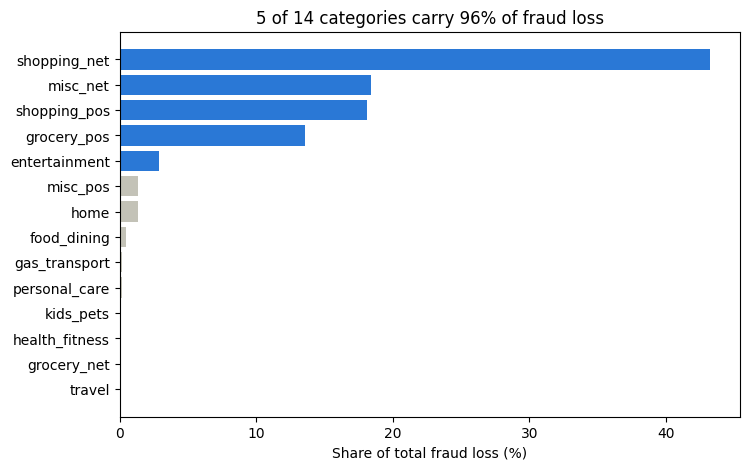

In [34]:
import matplotlib.pyplot as plt

chart_data = share.sort_values()
colors = ['#c3c2b7'] * 9 + ['#2a78d6'] * 5

plt.figure(figsize=(8, 5))
plt.barh(chart_data.index, chart_data, color=colors)
plt.title('5 of 14 categories carry 96% of fraud loss')
plt.xlabel('Share of total fraud loss (%)')
plt.savefig('loss_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

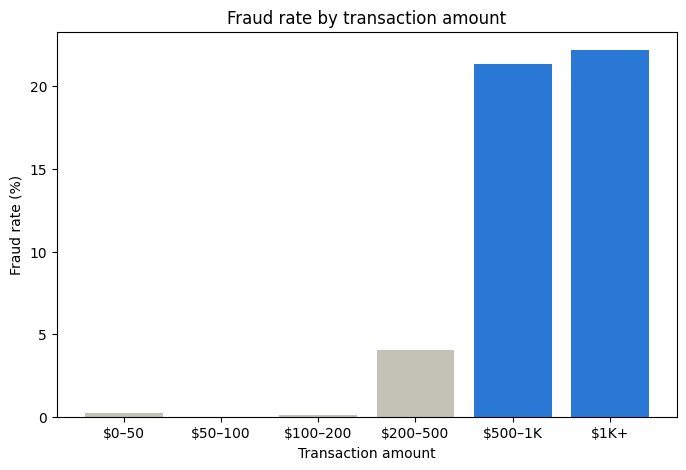

In [35]:
labels = ['$0–50', '$50–100', '$100–200', '$200–500', '$500–1K', '$1K+']
colors = ['#c3c2b7'] * 4 + ['#2a78d6'] * 2

plt.figure(figsize=(8, 5))
plt.bar(labels, fraud_rate, color=colors)
plt.title('Fraud rate by transaction amount')
plt.ylabel('Fraud rate (%)')
plt.xlabel('Transaction amount')
plt.savefig('fraud_rate_by_amount.png', dpi=150, bbox_inches='tight')
plt.show()